In [10]:
import os
import glob
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import cv2
from collections import OrderedDict


In [11]:
!nvidia-smi
!python -c "import torch; print(torch.__version__); print(torch.version.cuda)"


Mon May 11 15:22:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.02              Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080        On  |   00000000:01:00.0  On |                  N/A |
|  0%   54C    P0             47W /  360W |    1823MiB /  16303MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
class DeepfakeDataset(Dataset):
    def __init__(self, file_list: list, transform=None):
        self.samples   = file_list
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


def _find_subdir(parent: str, name_lower: str) -> str:
    if not os.path.isdir(parent):
        raise FileNotFoundError(f"Directory not found: {parent}")
    for entry in os.listdir(parent):
        if entry.lower() == name_lower and os.path.isdir(os.path.join(parent, entry)):
            return os.path.join(parent, entry)
    raise FileNotFoundError(
        f"Could not find '{name_lower}' (case-insensitive) inside {parent}\n"
        f"Available entries: {os.listdir(parent)}"
    )


def load_presplit(dataset_root: str):
    EXTS      = (".jpg", ".jpeg", ".png", ".webp")
    CLASS_MAP = {"deepfake": 1, "original": 0}

    def gather(split_name_lower: str):
        samples   = []
        split_dir = _find_subdir(dataset_root, split_name_lower)
        for cls_lower, label in CLASS_MAP.items():
            cls_dir = _find_subdir(split_dir, cls_lower)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(EXTS):
                    samples.append((os.path.join(cls_dir, fname), label))
        return samples

    train_samples = gather("train")
    val_samples   = gather("validation")

    for split_name, samples in [("Train", train_samples), ("Validation", val_samples)]:
        fake = sum(1 for _, l in samples if l == 1)
        real = sum(1 for _, l in samples if l == 0)
        print(f"{split_name} → deepfake: {fake:,}  original: {real:,}  total: {len(samples):,}")
        if fake == 0 or real == 0:
            print(f"    WARNING: {split_name} split has only one class — model cannot learn!")
        ratio = max(fake, real) / max(min(fake, real), 1)
        if ratio > 3:
            print(f"    WARNING: {split_name} class imbalance ratio {ratio:.1f}x — consider WeightedRandomSampler")

    return train_samples, val_samples


## Transforms

In [13]:
_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225],
)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    _normalize,
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    _normalize,
])


## Model
`Sigmoid` removed from forward pass — use `BCEWithLogitsLoss` instead for numerical stability.

EDIT: ändrar tillvaka


In [14]:
class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv2d(3,   32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.10),

            # Block 2
            nn.Conv2d(32,  64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.10),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=0.10),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(p=0.50),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(self.conv_blocks(x))

## Debug utilities
Run these before the training loop to catch data/gradient issues early.

In [15]:
def debug_dataloader(loader, num_batches=3):
    print("\n─── Dataloader Debug ────────────────────────────────")
    all_labels = []
    for i, (images, labels) in enumerate(loader):
        if i >= num_batches:
            break
        all_labels.extend(labels.tolist())
        print(f"\nBatch {i+1}:")
        print(f"  images shape     : {images.shape}")
        print(f"  images min/max/mean : {images.min():.3f} / {images.max():.3f} / {images.mean():.3f}")
        print(f"  labels (first 8) : {labels[:8].tolist()}")
        print(f"  label dist       : {int(sum(labels))} fake, {int(len(labels)-sum(labels))} real")
        if torch.isnan(images).any():
            print("  ⚠️  NaN values in images!")
        if images.max() == images.min():
            print("  ⚠️  All pixels identical — images may be blank!")
    fake = sum(1 for l in all_labels if l == 1)
    real = len(all_labels) - fake
    print(f"\nSampled {num_batches} batches total: {fake} fake  {real} real")
    print("─────────────────────────────────────────────────────\n")


def debug_first_backward(model, loader, criterion, device):
    print("\n─── Gradient Debug (first batch) ────────────────────")
    model.train()
    images, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.float().unsqueeze(1).to(device)

    optimizer_tmp = torch.optim.Adam(model.parameters(), lr=0.001)
    optimizer_tmp.zero_grad()
    preds = model(images)
    loss  = criterion(preds, labels)
    loss.backward()

    print(f"  raw logits (first 8) : {preds[:8].detach().cpu().squeeze().tolist()}")
    print(f"  labels     (first 8) : {labels[:8].cpu().squeeze().tolist()}")
    print(f"  loss                 : {loss.item():.6f}")

    zero_grad_layers = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            g = param.grad.abs()
            if g.max().item() == 0:
                zero_grad_layers.append(name)
            else:
                print(f"  grad [{name}]: mean={g.mean():.2e}  max={g.max():.2e}")

    if zero_grad_layers:
        print(f"  ⚠️  Zero gradients in: {zero_grad_layers}")
    else:
        print("  ✓ All layers have non-zero gradients")

    # Check if logits are all nearly identical (saturated)
    logit_vals = preds.detach().cpu().squeeze()
    if logit_vals.std().item() < 0.01:
        print(f"  ⚠️  Logits have near-zero variance ({logit_vals.std().item():.4f}) — model output is constant")
    else:
        print(f"  ✓ Logit std = {logit_vals.std().item():.4f}  (healthy if > 0.1)")

    print("─────────────────────────────────────────────────────\n")
    model.zero_grad()


## Training loop

In [16]:
def run_epoch(model, loader, optimizer, criterion, device, training: bool):
    model.train() if training else model.eval()
    total_loss, correct = 0.0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            if training:
                optimizer.zero_grad()

            preds = model(images)
            loss  = criterion(preds, labels)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            # BCELoss: preds are probabilities, so compare with > 0.5
            correct    += ((preds > 0.5).float() == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n

In [17]:
def plot_curves(history: dict, save_path: str = "training_curves.png"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor("#0f1117")
    for ax in (ax1, ax2):
        ax.set_facecolor("#1a1d27")
        ax.tick_params(colors="#aab0c6")
        ax.spines[:].set_color("#2e3248")
        ax.xaxis.label.set_color("#aab0c6")
        ax.yaxis.label.set_color("#aab0c6")
        ax.title.set_color("#e0e4f0")
    ax1.plot(epochs, history["train_loss"], color="#7c6dfa", linewidth=2, marker="o", markersize=4, label="Train")
    ax1.plot(epochs, history["val_loss"],   color="#f97583", linewidth=2, marker="s", markersize=4, label="Val", linestyle="--")
    ax1.set_title("Loss", fontsize=14, pad=10)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
    ax1.legend(framealpha=0.2, labelcolor="#e0e4f0")
    ax1.grid(alpha=0.12, color="#aab0c6")
    ax2.plot(epochs, [a * 100 for a in history["train_acc"]], color="#56d364", linewidth=2, marker="o", markersize=4, label="Train")
    ax2.plot(epochs, [a * 100 for a in history["val_acc"]],   color="#f0883e", linewidth=2, marker="s", markersize=4, label="Val", linestyle="--")
    ax2.set_title("Accuracy", fontsize=14, pad=10)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 100)
    ax2.legend(framealpha=0.2, labelcolor="#e0e4f0")
    ax2.grid(alpha=0.12, color="#aab0c6")
    fig.suptitle("Deepfake CNN — Training & Validation Curves", fontsize=15, color="#e0e4f0", y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"Curves saved → {save_path}")


def evaluate_metrics(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = model(images)
            # using Sigmoid, prob > 0.5
            binary = (preds > 0.5).float().cpu().squeeze(1)
            all_preds.extend(binary.tolist())
            all_labels.extend(labels.tolist())
    f1        = f1_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall    = recall_score(all_labels, all_preds)
    print("\n─── Final Validation Metrics ───────────────────")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print("────────────────────────────────────────────────")

Loading data from croped_data ...
Train → deepfake: 5,959  original: 5,963  total: 11,922
Validation → deepfake: 2,506  original: 2,511  total: 5,017
  → Found 11922 training samples
  → Found 5017 validation samples
Using device: cuda:0
No checkpoint found — starting from scratch.
Epoch [001/50] Train Loss: 3.8421 | Train Acc: 49.71%  ||  Val Loss: 0.7106 | Val Acc: 52.50%
Epoch [002/50] Train Loss: 0.7188 | Train Acc: 51.01%  ||  Val Loss: 0.6845 | Val Acc: 54.02%
Epoch [003/50] Train Loss: 0.6874 | Train Acc: 53.37%  ||  Val Loss: 0.6779 | Val Acc: 53.00%
Epoch [004/50] Train Loss: 0.6786 | Train Acc: 55.85%  ||  Val Loss: 0.6748 | Val Acc: 56.63%
Epoch [005/50] Train Loss: 0.6709 | Train Acc: 56.17%  ||  Val Loss: 0.6330 | Val Acc: 62.41%
Epoch [006/50] Train Loss: 0.6596 | Train Acc: 58.51%  ||  Val Loss: 0.6387 | Val Acc: 59.88%
Epoch [007/50] Train Loss: 0.6535 | Train Acc: 59.40%  ||  Val Loss: 0.6201 | Val Acc: 64.68%
Epoch [008/50] Train Loss: 0.6457 | Train Acc: 60.95%  ||  

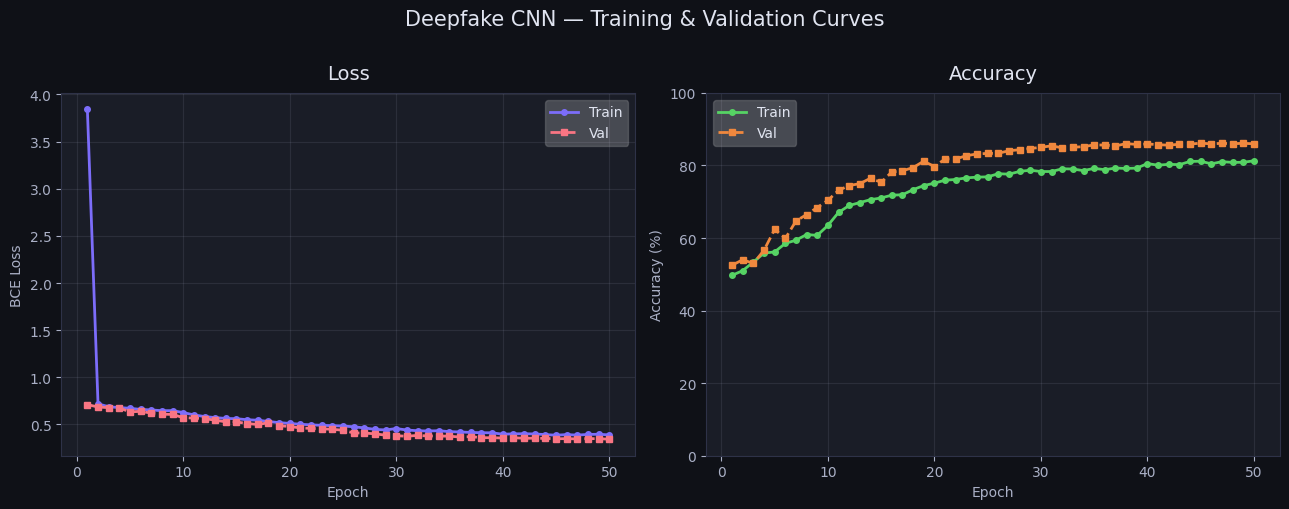

Curves saved → checkpoints/training_curves.png


In [ ]:
if __name__ == "__main__":

    # Original Kaggle Dataset
    # DATASET_ROOT = "/kaggle/input/datasets/fragdude44/dataset/dataset"
    
    # Generic Dataset
    DATASET_ROOT = "croped_data"

    print(f"Loading data from {DATASET_ROOT} ...")

    # If the splits are already on disk ("Train" and "Validation/Test" folders):
    # e.g., dataset_root/Train/deepfake, dataset_root/Validation/original, etc.
    # train_samples = load_presplit(DATASET_ROOT, split="Train", valid_exts=(".png", ".jpg", ".jpeg", ".mp4", ".avi"))
    # val_samples   = load_presplit(DATASET_ROOT, split="Validation", valid_exts=(".png", ".jpg", ".jpeg", ".mp4", ".avi"))
    train_samples, val_samples = load_presplit(DATASET_ROOT)

    if not train_samples:
        print(" CRITICAL ERROR: Found 0 train samples! Check DATASET_ROOT and folder structure.")
        sys.exit(1)
        
    print(f"  → Found {len(train_samples)} training samples")
    print(f"  → Found {len(val_samples)} validation samples")

    train_ds = DeepfakeDataset(train_samples, transform=train_transforms)
    val_ds   = DeepfakeDataset(val_samples,   transform=val_transforms)

    train_loader = DataLoader(train_ds, batch_size=160, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=160, shuffle=False,
                              num_workers=2, pin_memory=True)

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = DeepfakeCNN()
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = torch.nn.DataParallel(model)
    model.to(device)

    # BCELoss: since we added Sigmoid back to the model
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999), weight_decay=0.0001)

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3) # gammal
    # scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) # ny, reducerar LR om loss inte improvar

    # ── Debug before training ─────────────────────────────────────────────────
    # debug_dataloader(train_loader, num_batches=3)
    # debug_first_backward(model, train_loader, criterion, device)

    NUM_EPOCHS    = 50
    PATIENCE      = 10
    CKPT_INTERVAL = 9
    CKPT_DIR      = "checkpoints"
    os.makedirs(CKPT_DIR, exist_ok=True)

    history          = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss    = float("inf")
    patience_counter = 0
    best_epoch       = 0
    start_epoch      = 1

    ckpt_files = sorted(glob.glob(os.path.join(CKPT_DIR, "deepfake_cnn_epoch*.pth")))
    if ckpt_files:
        latest_ckpt = ckpt_files[-1]
        print(f"Resuming from checkpoint: {latest_ckpt}")
        checkpoint = torch.load(latest_ckpt, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch   = checkpoint["epoch"] + 1
        best_val_loss = checkpoint["val_loss"]
        history       = checkpoint.get("history", history)
        print(f"Resumed at epoch {checkpoint['epoch']}  |  val_loss {best_val_loss:.4f}")
    else:
        print("No checkpoint found — starting from scratch.")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, device, training=True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, criterion, device, training=False)
        scheduler.step() # om scheduler2 add val_loss i pararmeter

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if epoch % CKPT_INTERVAL == 0:
            ckpt_path = os.path.join(CKPT_DIR, f"deepfake_cnn_epoch{epoch:03d}.pth")
            torch.save({
                "epoch":                epoch,
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_loss":             va_loss,
                "val_acc":              va_acc,
                "history":              history,
            }, ckpt_path)
            print(f"  Checkpoint saved → {ckpt_path}")

        print(f"Epoch [{epoch:03d}/{NUM_EPOCHS}] "
              f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}%  ||  "
              f"Val Loss: {va_loss:.4f} | Val Acc: {va_acc*100:.2f}%")

        # Early Stopping
        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_epoch    = epoch
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best_model.pth"))

            # # Save EVERYTHING for the best model, just like a regular checkpoint. om vi vill resume training med anna shceduler
            # torch.save({
            #     "epoch":                epoch,
            #     "model_state_dict":     model.state_dict(),
            #     "optimizer_state_dict": optimizer.state_dict(),
            #     "scheduler_state_dict": scheduler.state_dict(),
            #     "val_loss":             va_loss,
            #     "val_acc":              va_acc,
            #     "history":              history,
            # }, os.path.join(CKPT_DIR, "best_model.pth"))

        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping triggered! No improvement in val loss for {PATIENCE} epochs.")
            print(f"  Best epoch was {best_epoch} with val_loss {best_val_loss:.4f}")
            break

    print("\nTraining Complete! Validating best model...")
    # Load best model for final evaluation
    best_weights = os.path.join(CKPT_DIR, "best_model.pth")
    if os.path.exists(best_weights):
        model.load_state_dict(torch.load(best_weights, map_location=device))
        evaluate_metrics(model, val_loader, device)


In [ ]:

    # Plot & Save Curves
plot_curves(history, save_path="checkpoints/training_curves.png")

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.eval()
        output = self.model(x)
        self.model.zero_grad()
        output.backward()
        pooled_grads = torch.mean(self.gradients, dim=[0, 2, 3])
        acts = self.activations.clone().detach()
        for i in range(acts.shape[1]):
            acts[:, i, :, :] *= pooled_grads[i]
        heatmap = torch.mean(acts, dim=1).squeeze().cpu().numpy()
        heatmap  = np.maximum(heatmap, 0)
        max_val  = heatmap.max()
        if max_val > 0:
            heatmap /= max_val
        return heatmap


def load_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
    if list(state_dict.keys())[0].startswith("module."):
        state_dict = OrderedDict((k[7:], v) for k, v in state_dict.items())
    model = DeepfakeCNN().to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def classify_image(image_path, model_path, output_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = load_model(model_path, device)

    # Fixed: index 11 is BatchNorm2d(128), not 10
    target_layer = model.conv_blocks[11]
    grad_cam     = GradCAM(model, target_layer)

    original_image = cv2.imread(image_path)
    if original_image is None:
        print(f"Error: Could not open image at {image_path}")
        return
    rgb_image    = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    pil_image    = Image.fromarray(rgb_image)
    input_tensor = val_transforms(pil_image).unsqueeze(0).to(device)

    heatmap = grad_cam(input_tensor)
    with torch.no_grad():
        logit = model(input_tensor)

    h, w, _ = original_image.shape
    heatmap  = cv2.resize(heatmap, (w, h))
    heatmap  = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    superimposed = np.clip(heatmap * 0.4 + original_image, 0, 255).astype(np.uint8)

    # logit > 0 == fake (prob > 0.5)
    label_text, color = ("Fake", (0, 0, 255)) if logit.item() > 0.5 else ("Real", (0, 255, 0))
    font      = cv2.FONT_HERSHEY_SIMPLEX
    text_size = cv2.getTextSize(label_text, font, 1, 2)[0]
    cv2.putText(superimposed, label_text,
                (w - text_size[0] - 10, text_size[1] + 10),
                font, 1, color, 2, cv2.LINE_AA)

    cv2.imwrite(output_path, superimposed)
    print(f"Prediction: {label_text} (logit={logit.item():.4f})")
    print(f"Output saved to: {output_path}")


In [33]:
MODEL_PATH        = "checkpoints/best_model.pth"
IMAGE_SOURCE      = "Dwayne-Johnson.webp"
OUTPUT_IMAGE = "output_gradcam.jpg" #inte 

classify_image(IMAGE_SOURCE, MODEL_PATH, OUTPUT_IMAGE)


Prediction: Real (logit=0.0035)
Output saved to: output_gradcam.jpg


In [ ]:
import shutil

for f in glob.glob("checkpoints/*.pth"):
    os.remove(f)
print("Checkpoints deleted.")


In [ ]:
import os

DATASET_ROOT = "/kaggle/input/datasets/fragdude44/dataset/dataset"

for split in ["train", "validation"]:
    split_path = os.path.join(DATASET_ROOT, split)
    if not os.path.exists(split_path):
        # try capitalised
        split_path = os.path.join(DATASET_ROOT, split.capitalize())
    print(f"\n{split_path}/")
    for cls_folder in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls_folder)
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg",".jpeg",".png",".webp"))])
        print(f"  {cls_folder}/  → {count} images")


/kaggle/input/datasets/fragdude44/dataset/dataset/Train/
  deepfake/  → 5967 images
  original/  → 5963 images

/kaggle/input/datasets/fragdude44/dataset/dataset/Validation/
  deepfake/  → 2506 images
  original/  → 2511 images


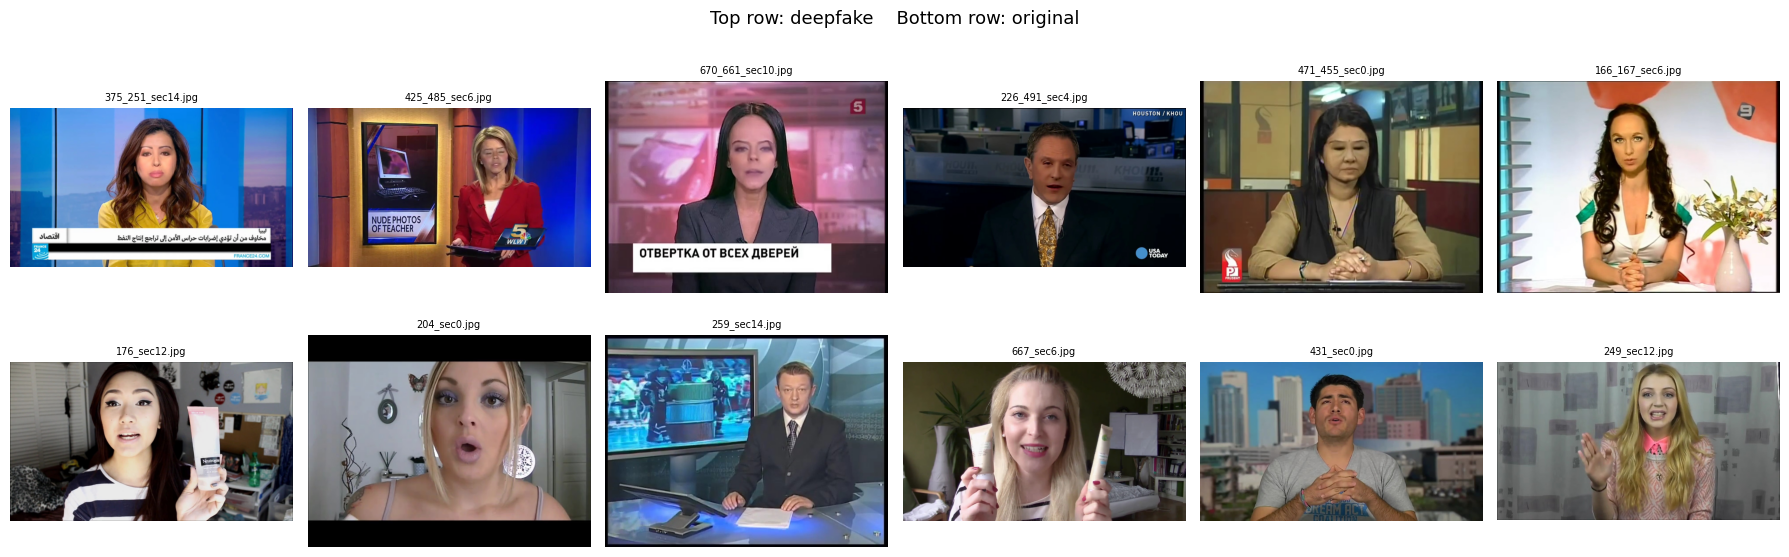

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

DATASET_ROOT = "/kaggle/input/datasets/fragdude44/dataset/dataset"

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("Top row: deepfake    Bottom row: original", fontsize=13)

for col in range(6):
    for row, cls in enumerate(["deepfake", "original"]):
        folder = os.path.join(DATASET_ROOT, "Train", cls)
        img_path = os.path.join(folder, random.choice(os.listdir(folder)))
        img = Image.open(img_path).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        axes[row, col].set_title(os.path.basename(img_path)[:20], fontsize=7)

plt.tight_layout()
plt.savefig("sample_images.png", dpi=120)
plt.show()

In [ ]:
from facenet_pytorch import MTCNN
import os
from PIL import Image

mtcnn = MTCNN(image_size=224, margin=20, keep_all=False)

def crop_and_save(src_root, dst_root):
    for split in ["Train", "Validation"]:
        for cls in ["deepfake", "original"]:
            src_dir = os.path.join(src_root, split, cls)
            dst_dir = os.path.join(dst_root, split, cls)
            os.makedirs(dst_dir, exist_ok=True)
            
            saved, skipped = 0, 0
            for fname in os.listdir(src_dir):
                if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                    continue
                img = Image.open(os.path.join(src_dir, fname)).convert("RGB")
                face = mtcnn(img)  # returns tensor or None
                if face is not None:
                    # convert back to PIL and save
                    face_pil = Image.fromarray(
                        (face.permute(1,2,0).numpy() * 128 + 127.5).clip(0,255).astype("uint8")
                    )
                    face_pil.save(os.path.join(dst_dir, fname))
                    saved += 1
                else:
                    skipped += 1
            
            print(f"{split}/{cls}: saved {saved}, no face detected {skipped}")

crop_and_save(
    "/kaggle/input/datasets/fragdude44/dataset/dataset",
    "/kaggle/working/dataset_faces"
)